In [2]:
#Assorted imports
import numpy as np
import pandas as pd
import h5py
import vaex
import pynbody
from pynbody.array import SimArray

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path

from astropy import units as u
from astropy.io import ascii, fits
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord,CartesianRepresentation,match_coordinates_sky

import functions_altered as fn 
from matched_filter_ani_altered import matched_filter_ani as mf

np.random.seed(0)

In [3]:
box = 'storm' 
num = 2 
D = 2000 
mlim_str = '26p5' 
name = f'{box}_4096_{num}_data_{D}_{mlim_str}'

size_kpc = 40 
pdist = (size_kpc/D) * (180/np.pi) 
year = 10
mlim = '25'
c1='px'
c2='py'
edgelength = 10 
plotdir = f'{box}_4096_{num}' 
bgcatpath = f"/home/otteleno/MAP/matched_filter_starters/bgcats/bgr{mlim}g{mlim}_for_mf_{int(edgelength)}deg.fits"

age = '10'
mh = '-2'

In [4]:
def fibonacci_angler(n):

    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/(n-1) ###ONLY GOES HALF WAY DOWN
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio

    declination_readable = [round(x*180/np.pi,1) for x in declination_array]
    azimuthal_readable = [round(np.mod(x*180/np.pi, 360),1) for x in  azimuthal_array]

    return declination_readable, azimuthal_readable

In [7]:
declination_readable, azimuthal_readable = fibonacci_angler(24)
print(declination_readable, azimuthal_readable)


[0.0, 17.0, 24.1, 29.6, 34.3, 38.5, 42.3, 45.9, 49.3, 52.5, 55.6, 58.6, 61.4, 64.2, 67.0, 69.6, 72.3, 74.9, 77.4, 80.0, 82.5, 85.0, 87.5, 90.0] [0.0, 222.5, 85.0, 307.5, 170.0, 32.5, 255.0, 117.4, 339.9, 202.4, 64.9, 287.4, 149.9, 12.4, 234.9, 97.4, 319.9, 182.4, 44.9, 267.4, 129.8, 352.3, 214.8, 77.3]


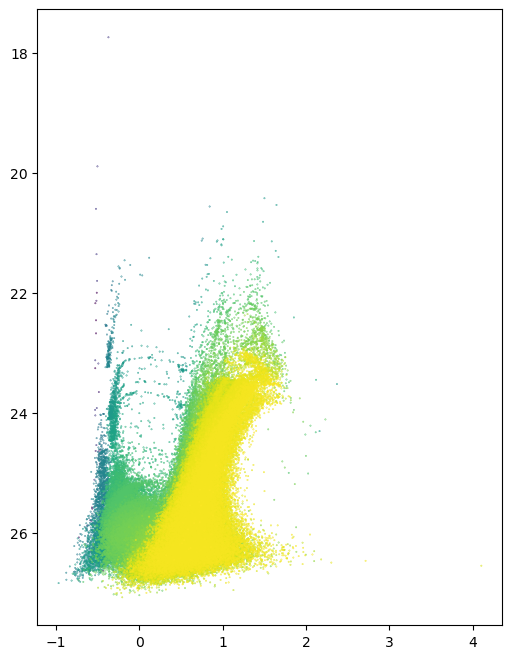

Saving ... 
Total number of signal CMD
1.0


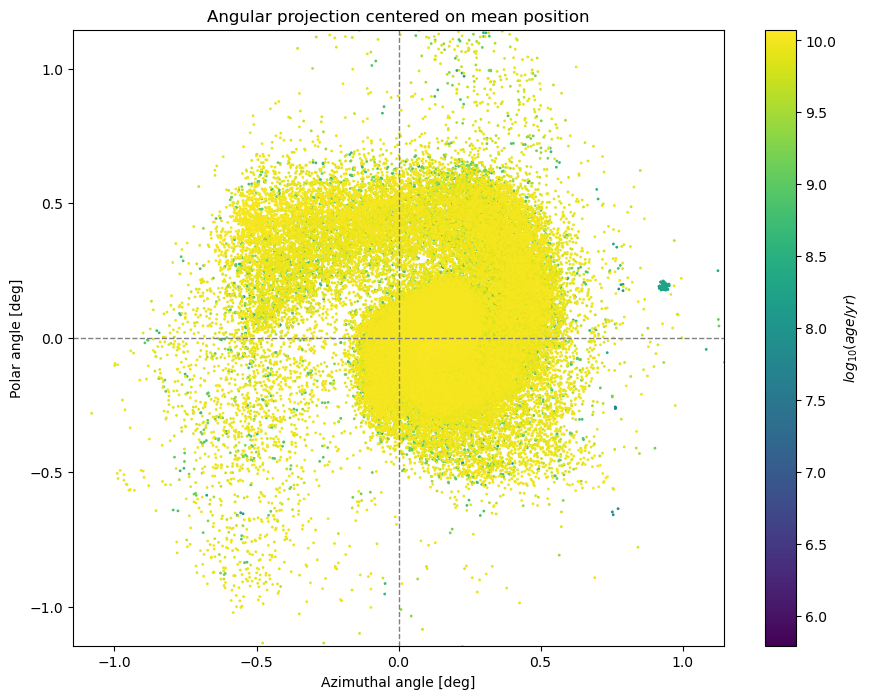

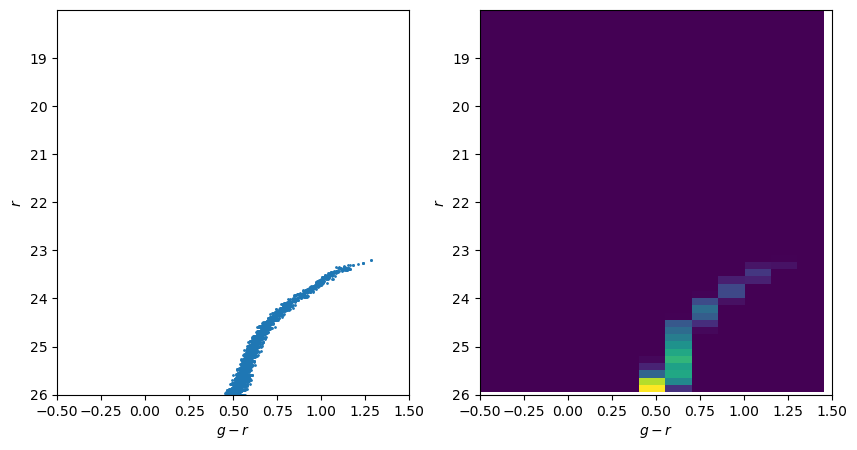

Total number of stars in background CMD
24050.978085084782


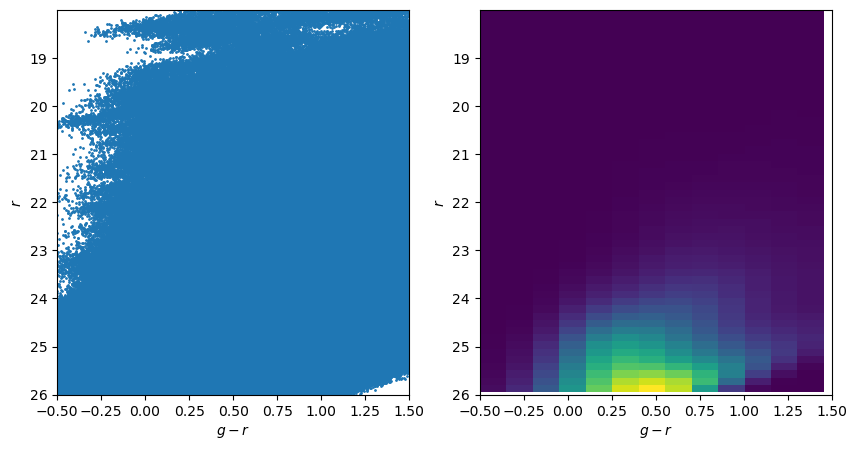

x min  -68.75493541569878
x max  68.75493541569878
y min  -68.75493541569878
y max  68.75493541569878


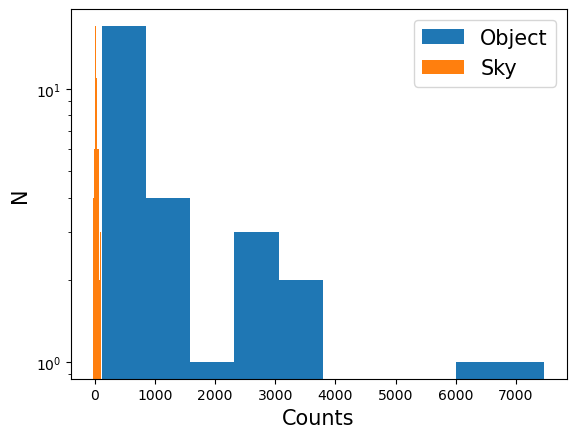

Sigma in smoothed stellar counts 28.86030656501273
Mean in smoothed stellar counts 25.762393621254624


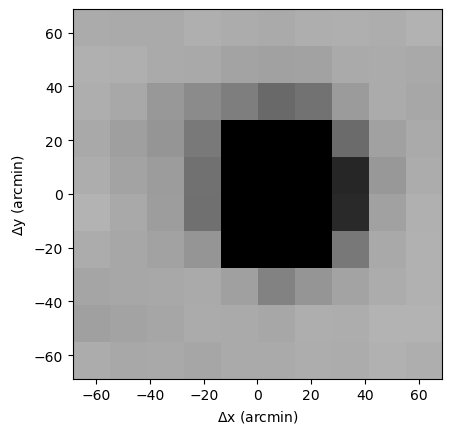

In [8]:
#MASTER LOOP


for i in range(len(declination_readable)):
            
    #First, load in data
    d= declination_readable[i] 
    a = azimuthal_readable[i]
             
    dwarfcatpath = f"/home/otteleno/MAP/automated_data/rotated_catalogs/{box}_{num}/{box}_{num}_d={d}_a={a}.h5"

    #Second, add background data
    save_path = f"/home/otteleno/MAP/automated_data/background_added_catalogs/{box}_{num}/{box}_{num}_d={d}_a={a}.fits"
    table_final = fn.bg_dwarf_combo(pdist,name,year,D,c1,c2,plotdir,dwarfcatpath,bgcatpath,edgelength,plot=False,save=True,my_save_path = save_path) 


    #Third, run MFA
    iso_info = 'parsec' 
    rmaglim=26
    
    numpix = 8000
    pix = (np.round(np.sqrt((2*pdist*60)**2 / numpix),2))
    catalog = save_path
    field = name+f'_mfmag{rmaglim}_{iso_info}{age}{mh}{c1}{c2}_{np.round(pdist*60,0)}'
    
    second_save_path = f"/home/otteleno/MAP/automated_data/matched_filter_catalogs/{box}_{num}/{box}_{num}_d={d}_a={a}.fits"
    
    mf(second_save_path, plotdir=f"../plots/{plotdir}/",
        field=field, 
        catalog=catalog, 
        signal_file=f"/home/otteleno/MAP/matched_filter_starters/signal_files/{iso_info}_{D}_{age}{mh}_signal_cmd_gr.txt", 
        plot=True, rmaglim = rmaglim, pix=pix, pdist=pdist*60)

    break
        
        